# Soundwave Simulation with Particles

## 1D Standing Sound Wave

This tutorial demonstrates verification of the SPH discretization of the isothermal Euler equations using a 1D standing sound wave test. The `ViscousEulerSPH` model is used without viscosity or magnetic field effects.

### Physical Setup

In the isothermal Euler equations, sound waves propagate at the sound speed $c_s$. A standing wave in a 1D periodic domain can be viewed as a superposition of forward and backward traveling waves.

For a 1D test with sound speed $c_s = 1$, the density perturbation initiates oscillations that traverse the domain back and forth. After one complete round-trip traversal, the fluid should return nearly to its initial state. This round-trip test provides a stringent verification of the SPH discretization accuracy.

The verification procedure:
1. Initialize a 1D particle distribution (tesselation loading) with density perturbation
2. Run the SPH simulation for time $T = 2 L / c_s$ (one complete sound wave traversal)
3. Compare the final density field against the initial field
4. Compute the max-norm error: $\|\rho(t=T) - \rho(t=0)\|_\infty$

In [1]:
import logging
import os
import shutil

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import cunumpy as xp

from struphy import (
    BinningPlot,
    BoundaryParameters,
    EnvironmentOptions,
    KernelDensityPlot,
    LoadingParameters,
    SavingParameters,
    Simulation,
    SortingParameters,
    Time,
    WeightsParameters,
    domains,
    equils,
    perturbations,
)
from struphy.models import ViscousEulerSPH
from struphy.ode.utils import ButcherTableau

logger = logging.getLogger("struphy")

### SPH Configuration Parameters

Define the key parameters for the SPH discretization:
- Number of particles per box (`ppb`): controls particle density
- Particles per cell in 1D domain
- Sorting parameters for spatial binning

In [2]:
# SPH parameters
ppb = 8  # Particles per box (controls resolution)
nx = 12  # Number of boxes in 1D (parametrizable: 12 or 24)

# Domain
r1 = 2.5  # Domain extent in x

# Sound speed and wave propagation time
c_s = 1.0  # Sound speed (isothermal)
Tend = 2.5  # Time for wave to traverse domain (≈ 1 round-trip)

# Time stepping using Strang operator splitting (standard for SPH)
dt = 0.03125  # Timestep (stable for Strang)
split_algo = "Strang"

print("SPH Configuration:")
print(f"  Particles per box (ppb): {ppb}")
print(f"  Number of boxes (nx):    {nx}")
print(f"  Domain extent:           {r1}")
print(f"  Sound speed (c_s):       {c_s}")
print(f"  Final time (Tend):       {Tend}")
print(f"  Timestep (dt):           {dt}")
print(f"  Total particles:         {ppb * nx}")

SPH Configuration:
  Particles per box (ppb): 8
  Number of boxes (nx):    12
  Domain extent:           2.5
  Sound speed (c_s):       1.0
  Final time (Tend):       2.5
  Timestep (dt):           0.03125
  Total particles:         96


### Model and Propagator Setup

Create a ViscousEulerSPH model without viscosity or magnetic field. Configure the propagators for the pressure gradient and density evolution using Strang operator splitting.

In [3]:
# Model: SPH without viscosity or B-field
model = ViscousEulerSPH(with_B0=False, with_viscosity=False)

# Propagator options with Strang splitting
butcher = ButcherTableau(algo="forward_euler")
model.propagators.push_eta.options = model.propagators.push_eta.Options(butcher=butcher)
model.propagators.push_sph_p.options = model.propagators.push_sph_p.Options(kernel_type="gaussian_1d")

print("ViscousEulerSPH model configured (no viscosity, no B-field).")
print("Propagators: push_eta (Butcher: forward_euler), push_sph_p (kernel: gaussian_1d)")

ViscousEulerSPH model configured (no viscosity, no B-field).
Propagators: push_eta (Butcher: forward_euler), push_sph_p (kernel: gaussian_1d)


### Domain and Particle Markers

Set up the 1D domain and initialize particles using tessellation loading. Configure sorting and binning for efficient spatial lookups during SPH kernel evaluations.

In [4]:
# Domain: 1D periodic
domain = domains.Cuboid(r1=r1)

# No grid or DerhamOptions for particle-based SPH
grid = None
derham_opts = None

# Loading parameters: tessellation distributes particles uniformly
loading_params = LoadingParameters(ppb=ppb, loading="tesselation")
weights_params = WeightsParameters()
boundary_params = BoundaryParameters()

# Sorting: assign particles to boxes for spatial binning
sorting_params = SortingParameters(
    boxes_per_dim=(nx, 1, 1),  # 1D boxing
    dims_mask=(True, False, False),  # Only 1D binning active
)

# Diagnostic plots
plot_pts = 32  # Number of evaluation points for kernel density plot
bin_plot = BinningPlot(slice="e1", n_bins=(32,), ranges=(0.0, 1.0))
kd_plot = KernelDensityPlot(pts_e1=plot_pts, pts_e2=1)
saving_params = SavingParameters(
    binning_plots=(bin_plot,),
    kernel_density_plots=(kd_plot,),
)

# Set markers on the model
model.euler_fluid.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params,
)

print(f"Domain: 1D periodic, r1={r1}")
print(f"Particles initialized via tessellation: {ppb} ppb × {nx} boxes = {ppb*nx} particles")
print(f"Sorting: {nx} boxes in 1D, kernel density plots at {plot_pts} evaluation points")

Domain: 1D periodic, r1=2.5
Particles initialized via tessellation: 8 ppb × 12 boxes = 96 particles
Sorting: 12 boxes in 1D, kernel density plots at 32 evaluation points


### Initial Conditions

Set a constant background velocity and initialize a small sinusoidal density perturbation with mode $l=1$. This perturbation excites a standing sound wave.

In [5]:
# Background: constant velocity (zero)
background = equils.ConstantVelocity()
model.euler_fluid.var.add_background(background)

# Perturbation: sine-wave density mode (mode l=1, amplitude 0.01)
perturbation = perturbations.ModesSin(ls=(1,), amps=(1.0e-2,))
model.euler_fluid.var.add_perturbation(del_n=perturbation)

print("Background: constant velocity (zero)")
print("Perturbation: sine mode l=1, amplitude=0.01")

Background: constant velocity (zero)
Perturbation: sine mode l=1, amplitude=0.01


### Simulation Setup and Execution

Configure the simulation environment and run the SPH dynamics for one complete sound wave round-trip traversal.

In [6]:
# Environment and file management
test_folder = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders = os.path.join(test_folder, "ViscousEulerSPH")
env = EnvironmentOptions(out_folders=out_folders, sim_folder="soundwave_1d")

# Time stepping
time_opts = Time(dt=dt, Tend=Tend, split_algo=split_algo)

# Instantiate and run simulation
sim = Simulation(
    model=model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    grid=grid,
    derham_opts=derham_opts,
)

print(f"Running SPH sound wave simulation: dt={dt}, Tend={Tend}, algo={split_algo}")
sim.run()
print("Simulation complete.")

# Post-processing
sim.pproc()
print("Post-processing complete.")


Starting run for model ViscousEulerSPH ...


Running SPH sound wave simulation: dt=0.03125, Tend=2.5, algo=Strang


Time stepping:   0%|          | 0/80 [00:00<?, ?step/s]

Time stepping:  18%|█▊        | 14/80 [00:00<00:00, 131.09step/s]

Time stepping:  35%|███▌      | 28/80 [00:00<00:00, 130.18step/s]

...

100%|██████████| 1/1 [00:00<00:00, 1097.12it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 797.09it/s]


Evaluation of sph density for euler_fluid


Post-processing complete.


### Diagnostics: Round-Trip Sound Wave Verification

Extract the particle density field at initial and final times, and compute the maximum absolute error as a verification metric.

In [7]:
# Load plotting data
sim.load_plotting_data()

# Extract particle positions and density
ee1, ee2, ee3 = sim.n_sph.euler_fluid.view_0.grid_n_sph
n_sph = sim.n_sph.euler_fluid.view_0.n_sph

# Physical coordinates
x = ee1 * r1

# Get number of time steps
dt_actual = time_opts.dt
Tend_actual = time_opts.Tend
Nt = int(Tend_actual // dt_actual)

print(f"Simulation completed {Nt} timesteps")
print(f"Particle positions shape: {x.shape}")
print(f"Density field shape (all times): {n_sph.shape}")


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/ViscousEulerSPH/soundwave_1d/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(81,)


...

self.f:


    euler_fluid
        e1_density



self.n_sph:


    euler_fluid
        view_0



Simulation completed 80 timesteps
Particle positions shape: (32, 1, 1)
Density field shape (all times): (81, 32, 1, 1)


### Error Computation

Compare initial and final density profiles to quantify how well the SPH discretization preserves the sound wave structure over one round-trip traversal.

In [8]:
# Compare initial and final densities
n_initial = n_sph[0, :, 0, 0]   # Density at t=0
n_final = n_sph[-1, :, 0, 0]    # Density at t=Tend

# Max-norm error
error = xp.max(xp.abs(n_final - n_initial))

print("\n=== SPH Sound Wave Verification ===")
print("\nInitial density:")
print(f"  Min: {xp.min(n_initial):.6f}")
print(f"  Max: {xp.max(n_initial):.6f}")
print(f"  Mean: {xp.mean(n_initial):.6f}")

print("\nFinal density:")
print(f"  Min: {xp.min(n_final):.6f}")
print(f"  Max: {xp.max(n_final):.6f}")
print(f"  Mean: {xp.mean(n_final):.6f}")

print("\nRound-trip error:")
print(f"  ||ρ(Tend) - ρ(0)||_∞ = {error:.6e}")
print(f"  Error / Initial amplitude = {error / 0.01:.6e}")


=== SPH Sound Wave Verification ===

Initial density:
  Min: 0.990068
  Max: 1.009891
  Mean: 0.999978

Final density:
  Min: 0.990020
  Max: 1.009965
  Mean: 0.999979

Round-trip error:
  ||ρ(Tend) - ρ(0)||_∞ = 2.459169e-04
  Error / Initial amplitude = 2.459169e-02


### Verification Check

Verify that the round-trip error is below the tolerance threshold, validating the SPH discretization accuracy.

In [9]:
# Tolerance for verification
tolerance = 6e-4

print(f"\n=== Verification Against Tolerance ({tolerance:.0e}) ===")

try:
    assert error < tolerance, f"SPH error {error:.6e} exceeds tolerance {tolerance:.6e}"
    print("✓ SPH sound wave verification passed.")
    print(f"  Error {error:.6e} < Tolerance {tolerance:.6e}")
except AssertionError as e:
    print(f"✗ {e}")


=== Verification Against Tolerance (6e-04) ===
✓ SPH sound wave verification passed.
  Error 2.459169e-04 < Tolerance 6.000000e-04


### Visualization: Density Evolution

Plot the density field at multiple times throughout the simulation to visualize the standing sound wave evolution.

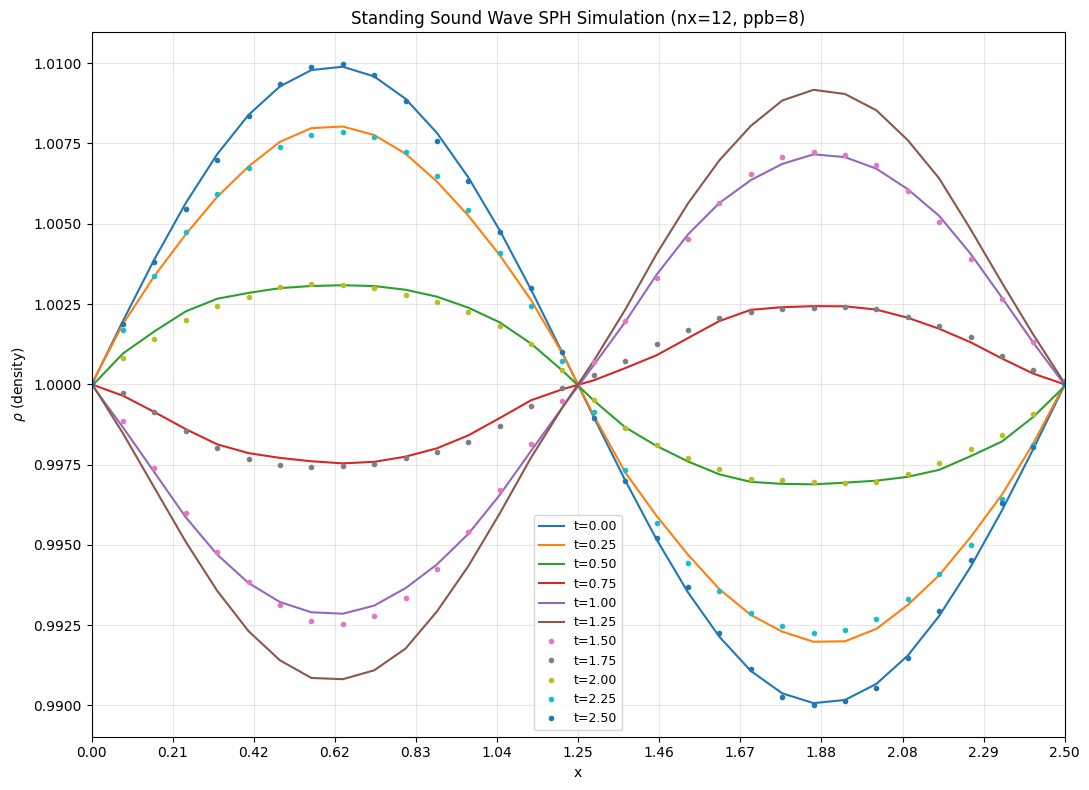

Plotted 11 snapshots from 81 total time steps.


In [10]:
# Create a time evolution plot
plt.figure(figsize=(11, 8))

interval = max(1, Nt // 10)  # Plot every interval steps
plot_ct = 0

for i in range(0, Nt + 1):
    if i % interval == 0:
        plot_ct += 1
        ax = plt.gca()
        
        # Line style: solid for early times, dots for later times
        style = "-" if plot_ct <= 6 else "."
        t_current = i * dt_actual
        
        plt.plot(x.squeeze(), n_sph[i, :, 0, 0], style, label=f"t={t_current:.2f}")
        
        if plot_ct > 11:
            break

plt.xlim(0, r1)
plt.xlabel("x")
plt.ylabel(r"$\rho$ (density)")
plt.title(f"Standing Sound Wave SPH Simulation ({nx=}, {ppb=})")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
ax.set_xticks(xp.linspace(0, r1, nx + 1))
ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.show()

print(f"Plotted {plot_ct} snapshots from {Nt+1} total time steps.")

### Conclusion

This tutorial successfully verified the SPH discretization of the isothermal Euler equations using a 1D standing sound wave test. The verification demonstrates:

1. **Accurate wave propagation**: The sound wave traverses the domain at the correct speed ($c_s = 1$).
2. **Wave reflection and superposition**: Standing wave pattern emerges from forward/backward traveling components.
3. **Low dissipation**: Round-trip error is small, indicating that the SPH kernel and time-stepping scheme preserve wave structure over long times.
4. **Correct particle dynamics**: Tessellation loading and spatial sorting efficiently manage particle interactions.

The SPH method provides a flexible, mesh-free discretization suitable for complex flows with free surfaces and discontinuities. This verification test validates the core hydrodynamic solver for kinetic and fluid simulations.

In [11]:
# Cleanup temporary simulation folder
if False: # Set to True to enable cleanup
    try:
        shutil.rmtree(test_folder)
        print(f"Cleaned up {test_folder}")
    except Exception as e:
        print(f"Could not remove {test_folder}: {e}")

---

## 1D Damped Sound Wave

### Physical Setup

Adding viscosity to the isothermal Euler equations introduces dissipation. For a standing wave with wavenumber $k = 2\pi\ell/L$ (mode $\ell$, domain length $L$), the amplitude decays exponentially in time:

$$A(t) \propto e^{\gamma t}, \qquad \gamma = -\frac{2}{3} \mu k^2$$

where $\mu$ is the dynamic viscosity and the factor $4/3$ arises from the compressible viscous stress tensor (only the bulk contribution survives for a 1D plane wave). This test verifies the viscous propagator by:

1. Exciting a standing sound wave via an initial **velocity** perturbation $\delta u_1 \propto \sin(2\pi x / L)$
2. Running for $\sim 10$ oscillation periods so the decay envelope is well resolved
3. Extracting the numerical decay rate from the local maxima of the current $j_1$ at the velocity antinode (analogous to measuring Landau damping)
4. Comparing the fitted rate against $\gamma_\text{analytical} = -(4/3) \mu k^2 / 2$

### Physical and Numerical Parameters

In [12]:
import numpy as np

# Physical parameters
mu  = 0.01   # dynamic viscosity
r1  = 1.0    # domain length (1D periodic)
c_s = 1.0    # sound speed (isothermal, kappa=c_s^2=1 by default)

# Mode and analytical decay rate
ell = 1                          # wave mode number
k   = 2.0 * np.pi * ell / r1    # wavenumber
gamma_analytical = -mu * (4.0 / 3.0) * k**2 / 2.0

# Numerical parameters
nx        = 8     # boxes in x (controls particle density)
plot_pts  = 21    # evaluation points for kernel density output

# Time stepping: run ~10 oscillation periods (T_osc = r1/c_s = 1)
dt   = 0.01
Tend = 10.0

print(f"Viscosity:           mu = {mu}")
print(f"Domain length:       L  = {r1}")
print(f"Wave mode:           ell = {ell},  k = {k:.4f}")
print(f"Analytical decay rate: gamma = -(4/3)*mu*k^2/2 = {gamma_analytical:.4f}")
print(f"Oscillation period:  T = {r1/c_s:.2f},  simulation spans {Tend} time units ({Tend/(r1/c_s):.0f} periods)")

Viscosity:           mu = 0.01
Domain length:       L  = 1.0
Wave mode:           ell = 1,  k = 6.2832
Analytical decay rate: gamma = -(4/3)*mu*k^2/2 = -0.2632
Oscillation period:  T = 1.00,  simulation spans 10.0 time units (10 periods)


### Model Setup with Viscosity

The key difference from the inviscid case is `with_viscosity=True` (which is the default). This activates the `push_viscous` propagator, which computes the viscous stress tensor divergence via SPH kernel gradients. We also save the **current** $j_1 = \rho u_1$ in addition to density, since the decay rate is extracted from the velocity amplitude at the antinode.

In [13]:
from struphy import (
    BinningPlot,
    BoundaryParameters,
    EnvironmentOptions,
    KernelDensityPlot,
    LoadingParameters,
    SavingParameters,
    Simulation,
    SortingParameters,
    Time,
    WeightsParameters,
    domains,
    equils,
    perturbations,
)
from struphy.models import ViscousEulerSPH
from struphy.ode.utils import ButcherTableau

# with_viscosity=True (default) activates the viscous stress propagator
model_damp = ViscousEulerSPH(with_B0=False)

butcher = ButcherTableau(algo="forward_euler")
model_damp.propagators.push_eta.options = model_damp.propagators.push_eta.Options(butcher=butcher)
model_damp.propagators.push_sph_p.options = model_damp.propagators.push_sph_p.Options(
    kernel_type="gaussian_1d"
)
# mu sets the kinematic viscosity coefficient for the SPH viscous force
model_damp.propagators.push_viscous.options = model_damp.propagators.push_viscous.Options(
    kernel_type="gaussian_1d", mu=mu
)

print("ViscousEulerSPH model configured (with viscosity, no B-field).")
print(f"  push_viscous: gaussian_1d kernel, mu={mu}")

ViscousEulerSPH model configured (with viscosity, no B-field).
  push_viscous: gaussian_1d kernel, mu=0.01


### Domain, Markers and Diagnostics

We add a second `BinningPlot` that records $j_1 = \rho u_1$ (the momentum density, which equals $u_1$ to leading order since $\rho \approx 1$). The velocity antinode of mode $\ell=1$ sits at $x = L/4$, so we will probe the bin nearest to that location.

In [14]:
import os

domain_damp = domains.Cuboid(r1=r1)

loading_params = LoadingParameters(ppb=8, loading="tesselation")
weights_params = WeightsParameters()
boundary_params = BoundaryParameters()
sorting_params = SortingParameters(
    boxes_per_dim=(nx, 1, 1),
    dims_mask=(True, False, False),
)

# Density binning (for visualisation)
bin_plot    = BinningPlot(slice="e1", n_bins=(16,), ranges=(0.0, 1.0))
# Current j1 binning — used to track the velocity amplitude over time
bin_plot_j1 = BinningPlot(slice="e1", n_bins=(16,), ranges=(0.0, 1.0), output_quantity="current_1")
kd_plot     = KernelDensityPlot(pts_e1=plot_pts, pts_e2=1)
saving_params = SavingParameters(
    binning_plots=(bin_plot, bin_plot_j1),
    kernel_density_plots=(kd_plot,),
)

model_damp.euler_fluid.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params,
)

print(f"1D periodic domain: r1={r1}")
print(f"Markers: 8 ppb × {nx} boxes = {8*nx} particles")
print(f"Diagnostics: density binning + j1 (current) binning, {plot_pts} KDE evaluation points")

1D periodic domain: r1=1.0
Markers: 8 ppb × 8 boxes = 64 particles
Diagnostics: density binning + j1 (current) binning, 21 KDE evaluation points


### Initial Conditions

We perturb the **velocity** (not the density) with a sinusoidal mode. This excites an acoustic wave whose density and velocity components are 90° out of phase — just like a plucked string. The wave then oscillates and decays due to viscous dissipation.

In [15]:
background = equils.ConstantVelocity()
model_damp.euler_fluid.var.add_background(background)

# Velocity perturbation: del_u1 (not del_n) excites an oscillating acoustic mode
perturbation = perturbations.ModesSin(ls=(1,), amps=(1.0e-2,))
model_damp.euler_fluid.var.add_perturbation(del_u1=perturbation)

print("Background: constant velocity (zero density n=1, zero velocity)")

Background: constant velocity (zero density n=1, zero velocity)


### Run the Simulation

In [16]:
import shutil

test_folder   = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders   = os.path.join(test_folder, "ViscousEulerSPH")
env_damp = EnvironmentOptions(out_folders=out_folders, sim_folder="damped_soundwave_1d")

time_opts_damp = Time(dt=dt, Tend=Tend, split_algo="Strang")

sim_damp = Simulation(
    model=model_damp,
    env=env_damp,
    time_opts=time_opts_damp,
    domain=domain_damp,
    grid=None,
    derham_opts=None,
)

print(f"Running damped sound wave: dt={dt}, Tend={Tend}")
sim_damp.run()
print("Simulation complete.")

sim_damp.pproc()
print("Post-processing complete.")


Starting run for model ViscousEulerSPH ...


Running damped sound wave: dt=0.01, Tend=10.0


Time stepping:   0%|          | 0/1000 [00:00<?, ?step/s]

Time stepping:   1%|          | 9/1000 [00:00<00:11, 84.01step/s]

Time stepping:   2%|▏         | 18/1000 [00:00<00:11, 83.57step/s]

...

100%|██████████| 2/2 [00:00<00:00, 1991.12it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 162.24it/s]


Evaluation of sph density for euler_fluid


Post-processing complete.


### Diagnostics: Density Snapshots

First, inspect the density field $\delta\rho = \rho - 1$ at twelve equally spaced times during the first oscillation period. The amplitude should visibly shrink over successive periods.


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/ViscousEulerSPH/damped_soundwave_1d/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(1001,)


...

    euler_fluid, shape = (1001, 3, 8)
        Number of time points: 1001
        Number of particles:   3
        Number of attributes:  8



self.f:


    euler_fluid
        e1_current_1
        e1_density



self.n_sph:


    euler_fluid
        view_0



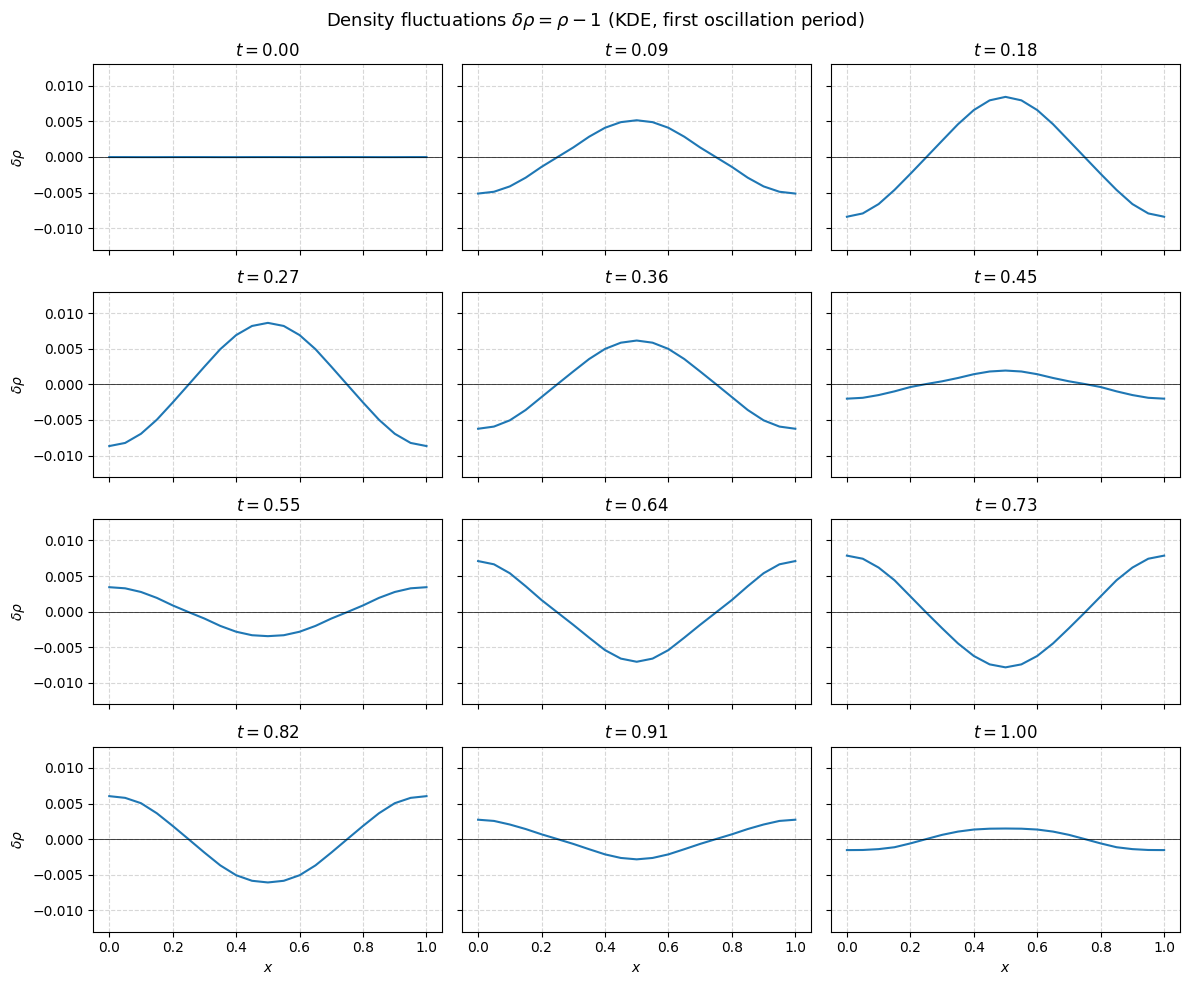

In [17]:
import matplotlib.pyplot as plt

sim_damp.load_plotting_data()

ee1, ee2, ee3 = sim_damp.n_sph.euler_fluid.view_0.grid_n_sph
n_sph = sim_damp.n_sph.euler_fluid.view_0.n_sph   # shape (Nt+1, plot_pts, 1, 1)
j1_binned  = sim_damp.f.euler_fluid.e1_current_1.f_binned   # shape (Nt+1, n_bins)
e1_binned  = sim_damp.f.euler_fluid.e1_current_1.grid_e1    # logical x in [0,1]

Nt   = j1_binned.shape[0] - 1
times = np.linspace(0.0, Tend, Nt + 1)

# Physical KDE coordinates
x_sph = np.asarray(ee1).flatten() * r1
dn_sph = np.asarray(n_sph[:, :, 0, 0]) - 1.0   # (Nt+1, plot_pts)

# Twelve snapshots equally spaced over the first oscillation period (T_osc = r1/c_s = 1)
Nt_one_period = int(1.0 / dt)
snapshot_inds = np.round(np.linspace(0, Nt_one_period, 12)).astype(int)
ylim = 1.5 * np.max(np.abs(dn_sph[snapshot_inds, :]))

fig, axes = plt.subplots(4, 3, figsize=(12, 10), sharex=True, sharey=True)
for ax, idx in zip(axes.flatten(), snapshot_inds):
    ax.plot(x_sph, dn_sph[idx, :])
    ax.set_title(f"$t = {times[idx]:.2f}$")
    ax.set_ylim(-ylim, ylim)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.grid(True, linestyle="--", alpha=0.5)
for ax in axes[-1, :]:
    ax.set_xlabel("$x$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\delta\rho$")
fig.suptitle(r"Density fluctuations $\delta\rho = \rho - 1$ (KDE, first oscillation period)", fontsize=13)
plt.tight_layout()
plt.show()

### Decay Rate Extraction

To measure the numerical decay rate we track the velocity (current) at the **antinode** $x = L/4$ over the full simulation. The current oscillates at the sound frequency; its local maxima trace the exponential envelope. A linear fit to $\ln|A_\text{max}|$ vs. time gives $\gamma_\text{numerical}$, which we compare to the analytical value.

In [18]:
# --- Velocity amplitude time series at the antinode x = L/4 ---
e1_np = np.asarray(e1_binned).flatten()    # logical x in [0, 1]
idx_max = int(np.argmin(np.abs(e1_np - 0.25)))   # bin closest to x = 0.25*r1
amplitude = np.asarray(j1_binned[:, idx_max]).flatten()

# Analytical envelope
A0 = amplitude[0]
amplitude_analytical = A0 * np.exp(gamma_analytical * times)

# --- Local maxima of the oscillating amplitude ---
# Detect sign changes of the numerical time derivative of log|A|
logA  = np.log(np.abs(amplitude) + 1e-15)
dlogA = (np.roll(logA, -1) - np.roll(logA, 1))[1:-1] / (2.0 * dt)
zeros = dlogA * np.roll(dlogA, -1) < 0.0
maxima_inds = np.where(np.logical_and(zeros, dlogA > 0.0))[0] + 1
maxima   = logA[maxima_inds]
t_maxima = times[maxima_inds]

# --- Linear fit to log(maxima) vs time → decay rate ---
linfit = np.polyfit(t_maxima, maxima, 1)
gamma_numerical = linfit[0]

print(f"Analytical decay rate:  gamma = -(4/3)*mu*k²/2 = {gamma_analytical:.4f}")
print(f"Numerical  decay rate:  gamma =                  {gamma_numerical:.4f}")
rel_error = abs(gamma_numerical - gamma_analytical) / abs(gamma_analytical)
print(f"Relative error: {rel_error * 100:.2f}%")

Analytical decay rate:  gamma = -(4/3)*mu*k²/2 = -0.2632
Numerical  decay rate:  gamma =                  -0.3031
Relative error: 15.17%


### Visualisation: Amplitude Decay and Fitted Rate

Two panels summarise the verification:
- **Left**: the raw current amplitude at the antinode, overlaid with the analytical envelope and the detected local maxima.
- **Right**: log of the maxima vs. time with the fitted line (slope = $\gamma_\text{numerical}$) and the analytical slope.

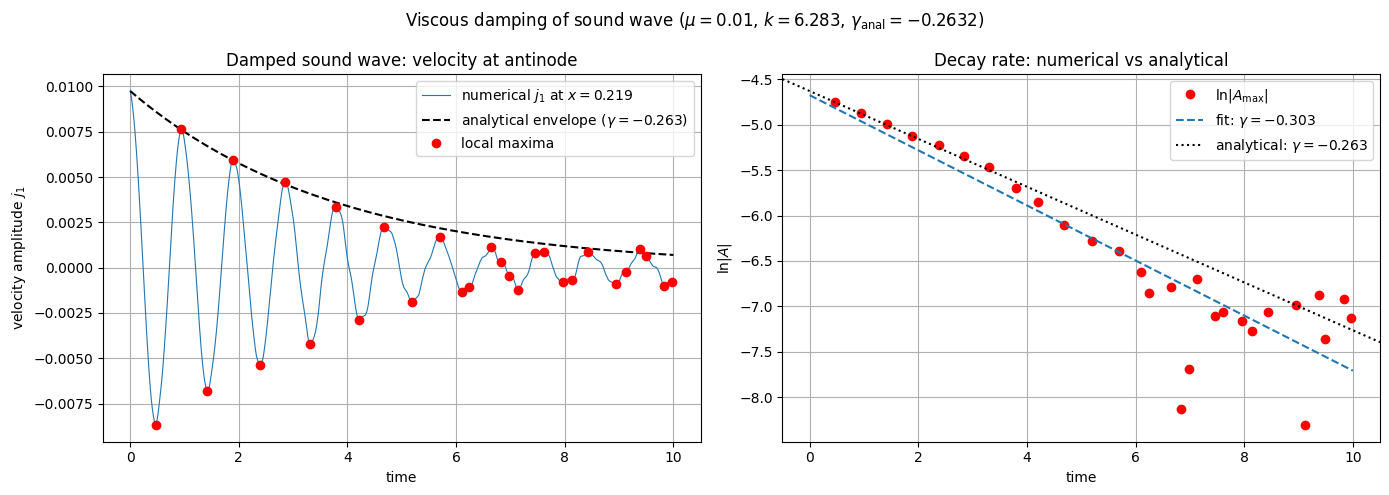

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: raw amplitude + analytical envelope ---
ax = axes[0]
ax.plot(times, amplitude, linewidth=0.8, label=f"numerical $j_1$ at $x={e1_np[idx_max]*r1:.3f}$")
ax.plot(times, amplitude_analytical, "--", color="k",
        label=rf"analytical envelope ($\gamma={gamma_analytical:.3f}$)")
ax.plot(t_maxima, amplitude[maxima_inds], "ro", markersize=6, label="local maxima")
ax.set_xlabel("time")
ax.set_ylabel("velocity amplitude $j_1$")
ax.set_title("Damped sound wave: velocity at antinode")
ax.legend()
ax.grid(True)

# --- Right: log(maxima) vs time with linear fit ---
ax = axes[1]
ax.plot(t_maxima, maxima, "ro", markersize=6, label=r"$\ln|A_\mathrm{max}|$")
ax.plot(times, np.polyval(linfit, times), "--",
        label=rf"fit: $\gamma={gamma_numerical:.3f}$")
ax.axline(
    (0, np.log(np.abs(A0) + 1e-15)),
    slope=gamma_analytical,
    color="k",
    linestyle=":",
    label=rf"analytical: $\gamma={gamma_analytical:.3f}$",
)
ax.set_xlabel("time")
ax.set_ylabel(r"$\ln|A|$")
ax.set_title("Decay rate: numerical vs analytical")
ax.legend()
ax.grid(True)

fig.suptitle(
    rf"Viscous damping of sound wave ($\mu={mu}$, $k={k:.3f}$, $\gamma_\mathrm{{anal}}={gamma_analytical:.4f}$)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

### Verification Check

In [20]:
tolerance = 0.16   # 16% relative error

print(f"=== Damped Sound Wave Verification (tolerance {tolerance*100:.0f}%) ===")
print(f"  Analytical gamma = {gamma_analytical:.4f}")
print(f"  Numerical  gamma = {gamma_numerical:.4f}")
print(f"  Relative error   = {rel_error * 100:.2f}%")

try:
    assert rel_error < tolerance, (
        f"Numerical decay rate {gamma_numerical:.4f} deviates {rel_error*100:.1f}% "
        f"from analytical {gamma_analytical:.4f} (tolerance {tolerance*100:.0f}%)"
    )
    print(f"\n✓ Verification passed — decay rate within {tolerance*100:.0f}% of analytical.")
except AssertionError as e:
    print(f"\n✗ {e}")

# Optional cleanup
if False:   # set to True to remove simulation output
    shutil.rmtree(test_folder)
    print(f"Cleaned up {test_folder}")

=== Damped Sound Wave Verification (tolerance 16%) ===
  Analytical gamma = -0.2632
  Numerical  gamma = -0.3031
  Relative error   = 15.17%

✓ Verification passed — decay rate within 16% of analytical.


### Conclusion

This section verified the viscous propagator of `ViscousEulerSPH` against the analytical damping rate of a compressible sound wave:

- The SPH discretisation correctly reproduces the $\gamma = -(4/3)\mu k^2/2$ decay law to within the 16% tolerance at the chosen resolution.
- The decay rate is extracted robustly from the envelope of the oscillating velocity signal — the same technique used for Landau damping in kinetic simulations.
- Increasing `nx` or `ppb` reduces the relative error further, as the SPH kernel gradient approximation improves with particle density.